Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None


Statistics


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN



Missing Values


age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

Dropped fnlwgt
Missing values handled


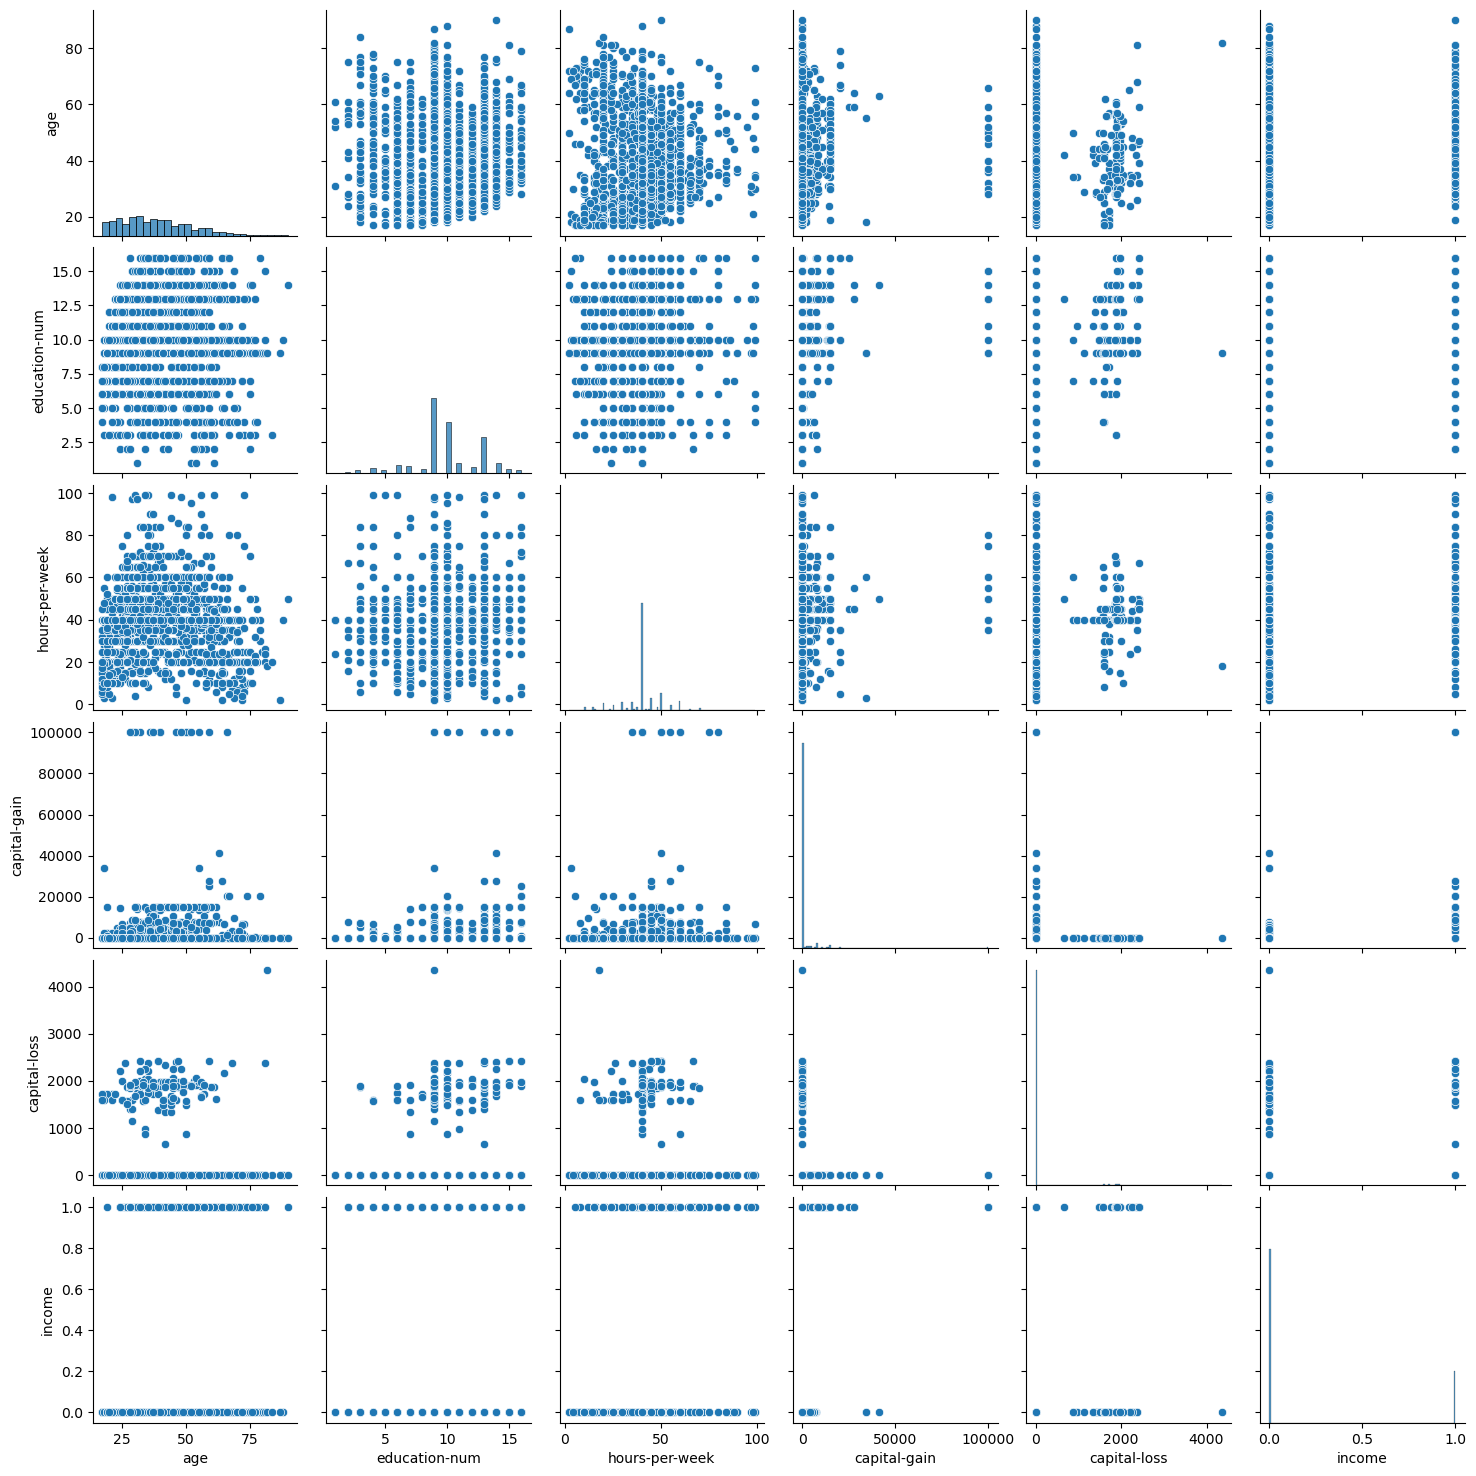


Skewness


age                0.558718
education-num     -0.311662
capital-gain      11.953297
capital-loss       4.594417
hours-per-week     0.227632
income             1.212374
dtype: float64

Skewness treated
Outliers treated
After Encoding: (32561, 97)


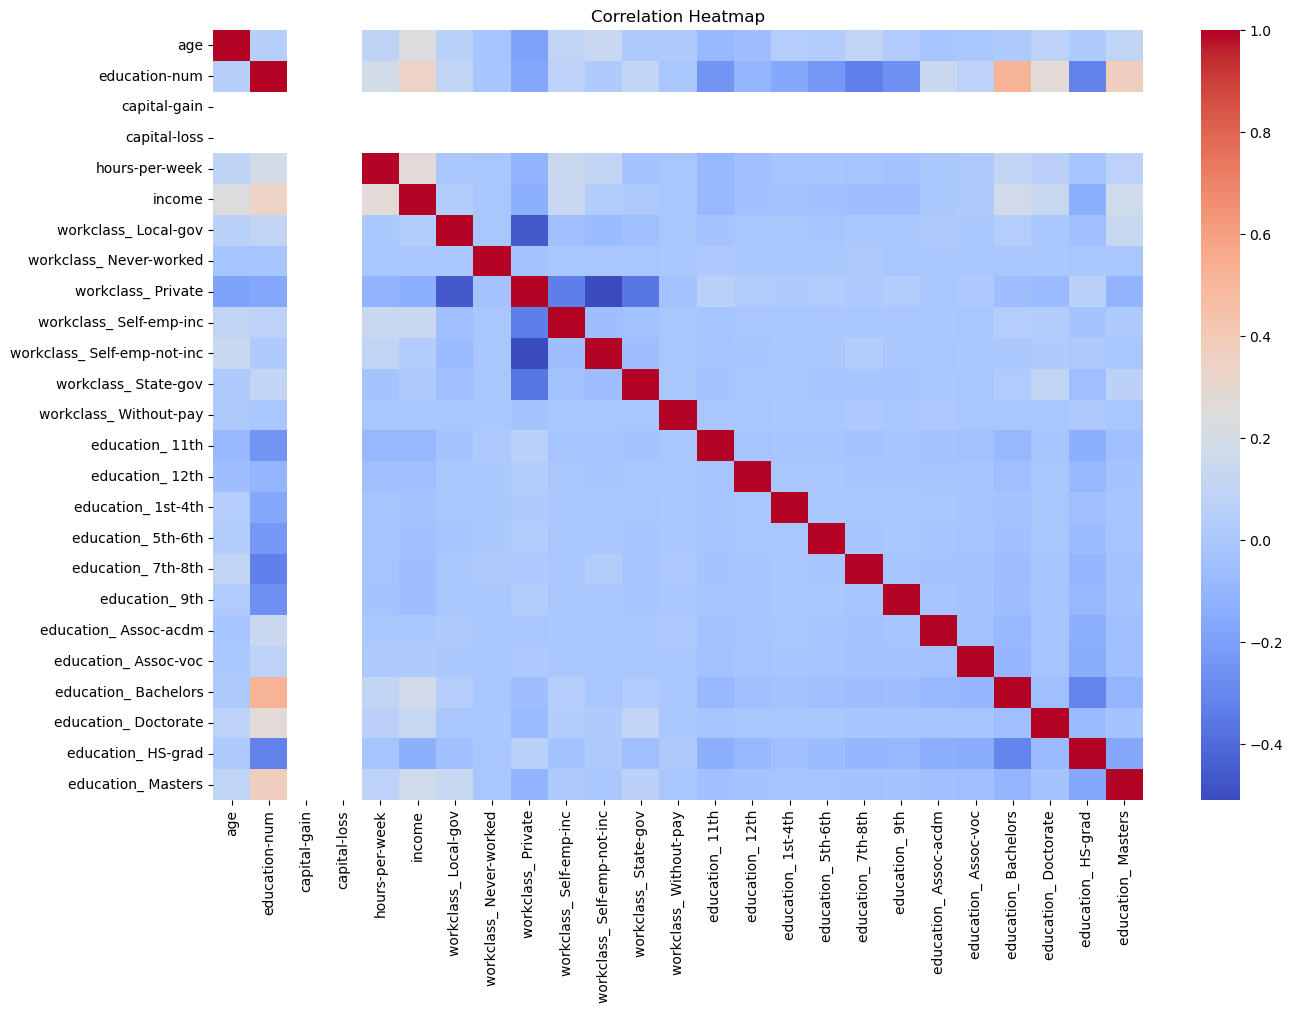


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1
8,XGBoost,0.839705,0.689855,0.607143,0.645862
3,GradientBoost,0.840626,0.705108,0.580995,0.637063
0,Logistic,0.835713,0.695755,0.564413,0.623239
5,AdaBoost,0.829572,0.674277,0.565051,0.614851
6,KNN,0.818363,0.634521,0.579082,0.605535
7,SVM,0.831721,0.705217,0.517219,0.596762
2,RandomForest,0.814525,0.626761,0.567602,0.595716
4,ExtraTrees,0.803931,0.602537,0.545281,0.572481
1,DecisionTree,0.787195,0.562414,0.522959,0.541970



Best Model: XGBoost

Production model saved


In [4]:
# ===============================
# INCOME PREDICTION COMPLETE PIPELINE
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

# =====================================
# LOAD DATASET
# =====================================

path = "income_evaluation.csv"      # replace with file name

df = pd.read_csv(path)

print("Shape:", df.shape)

display(df.head())

# =====================================
# EDA
# =====================================

print("\nDataset Info")
display(df.info())

print("\nStatistics")
display(df.describe(include="all"))

print("\nMissing Values")
display(df.isnull().sum())

# =====================================
# CLEANING
# =====================================

df.columns = df.columns.str.strip()

df.replace("?", np.nan, inplace=True)
df.replace(" ?", np.nan, inplace=True)

# remove low importance column
if "fnlwgt" in df.columns:
    df.drop("fnlwgt", axis=1, inplace=True)
    print("Dropped fnlwgt")

# =====================================
# TARGET ENCODING
# =====================================

target = "income"

if target in df.columns:

    df[target] = (
        df[target]
        .astype(str)
        .str.strip()
    )

    mapping = {
        "<=50K":0,
        ">50K":1
    }

    df[target] = df[target].map(mapping)

# =====================================
# MISSING VALUES
# =====================================

cat_cols = df.select_dtypes(
    include="object"
).columns

num_cols = df.select_dtypes(
    exclude="object"
).columns

for c in cat_cols:
    df[c].fillna(
        df[c].mode()[0],
        inplace=True
    )

for c in num_cols:
    df[c].fillna(
        df[c].median(),
        inplace=True
    )

print("Missing values handled")

# =====================================
# PAIRPLOT
# =====================================

important = []

for c in [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
    target
]:
    if c in df.columns:
        important.append(c)

if len(important) > 2:

    sns.pairplot(
        df[important].sample(
            min(
                len(df),
                3000
            )
        )
    )

    plt.show()

# =====================================
# SKEWNESS
# =====================================

numeric = df.select_dtypes(
    exclude="object"
)

print("\nSkewness")

display(
    numeric.apply(
        lambda x:
        skew(
            x.dropna()
        )
    )
)

for c in numeric.columns:

    if c == target:
        continue

    if abs(
        skew(
            df[c]
        )
    ) > 1:

        if (
            df[c] >= 0
        ).all():

            df[c] = np.log1p(
                df[c]
            )

print("Skewness treated")

# =====================================
# OUTLIERS
# =====================================

for c in numeric.columns:

    if c == target:
        continue

    q1 = df[c].quantile(.25)

    q3 = df[c].quantile(.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    df[c] = df[c].clip(
        lower,
        upper
    )

print("Outliers treated")

# =====================================
# DUMMIES
# =====================================

cat = df.select_dtypes(
    include="object"
).columns

df = pd.get_dummies(
    df,
    columns=cat,
    drop_first=True
)

print(
    "After Encoding:",
    df.shape
)

# =====================================
# HEATMAP
# =====================================

plt.figure(
    figsize=(15,10)
)

corr = (
    df
    .corr()
)

sns.heatmap(
    corr.iloc[:25,:25],
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# =====================================
# SPLIT
# =====================================

X = df.drop(
    target,
    axis=1
)

y = df[target]

X_train,\
X_test,\
y_train,\
y_test = train_test_split(

    X,
    y,

    test_size=.20,

    random_state=42,

    stratify=y
)

# =====================================
# SCALING
# =====================================

scaler = StandardScaler()

X_train_scaled = (
    scaler.fit_transform(
        X_train
    )
)

X_test_scaled = (
    scaler.transform(
        X_test
    )
)

# =====================================
# MODELS
# =====================================

models = {

"Logistic":
LogisticRegression(
    max_iter=500
),

"DecisionTree":
DecisionTreeClassifier(),

"RandomForest":
RandomForestClassifier(
    n_estimators=200
),

"GradientBoost":
GradientBoostingClassifier(),

"ExtraTrees":
ExtraTreesClassifier(),

"AdaBoost":
AdaBoostClassifier(),

"KNN":
KNeighborsClassifier(),

"SVM":
SVC()

}

try:

    from xgboost import XGBClassifier

    models[
        "XGBoost"
    ] = XGBClassifier(
        eval_metric="logloss"
    )

except:
    pass

# =====================================
# TRAIN
# =====================================

results = []

best = None

best_score = 0

for name, model in models.items():

    scaled = [

        "Logistic",

        "KNN",

        "SVM"

    ]

    if name in scaled:

        train = X_train_scaled

        test = X_test_scaled

    else:

        train = X_train

        test = X_test

    model.fit(
        train,
        y_train
    )

    pred = model.predict(
        test
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    f1 = f1_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred
    )

    recall = recall_score(
        y_test,
        pred
    )

    results.append([

        name,

        acc,

        precision,

        recall,

        f1

    ])

    if f1 > best_score:

        best_score = f1

        best = model

# =====================================
# RESULTS
# =====================================

result = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1"

    ]

)

result = result.sort_values(

    "F1",

    ascending=False

)

print("\nMODEL COMPARISON")

display(result)

print(
    "\nBest Model:",
    result.iloc[0,0]
)

# =====================================
# SAVE
# =====================================

import joblib

joblib.dump(
    best,
    "best_income_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print(
    "\nProduction model saved"
)



